# Import Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
df = pd.read_csv("combined_data.csv", low_memory=False, na_values=['', ' '])

df.shape

(433825, 17)

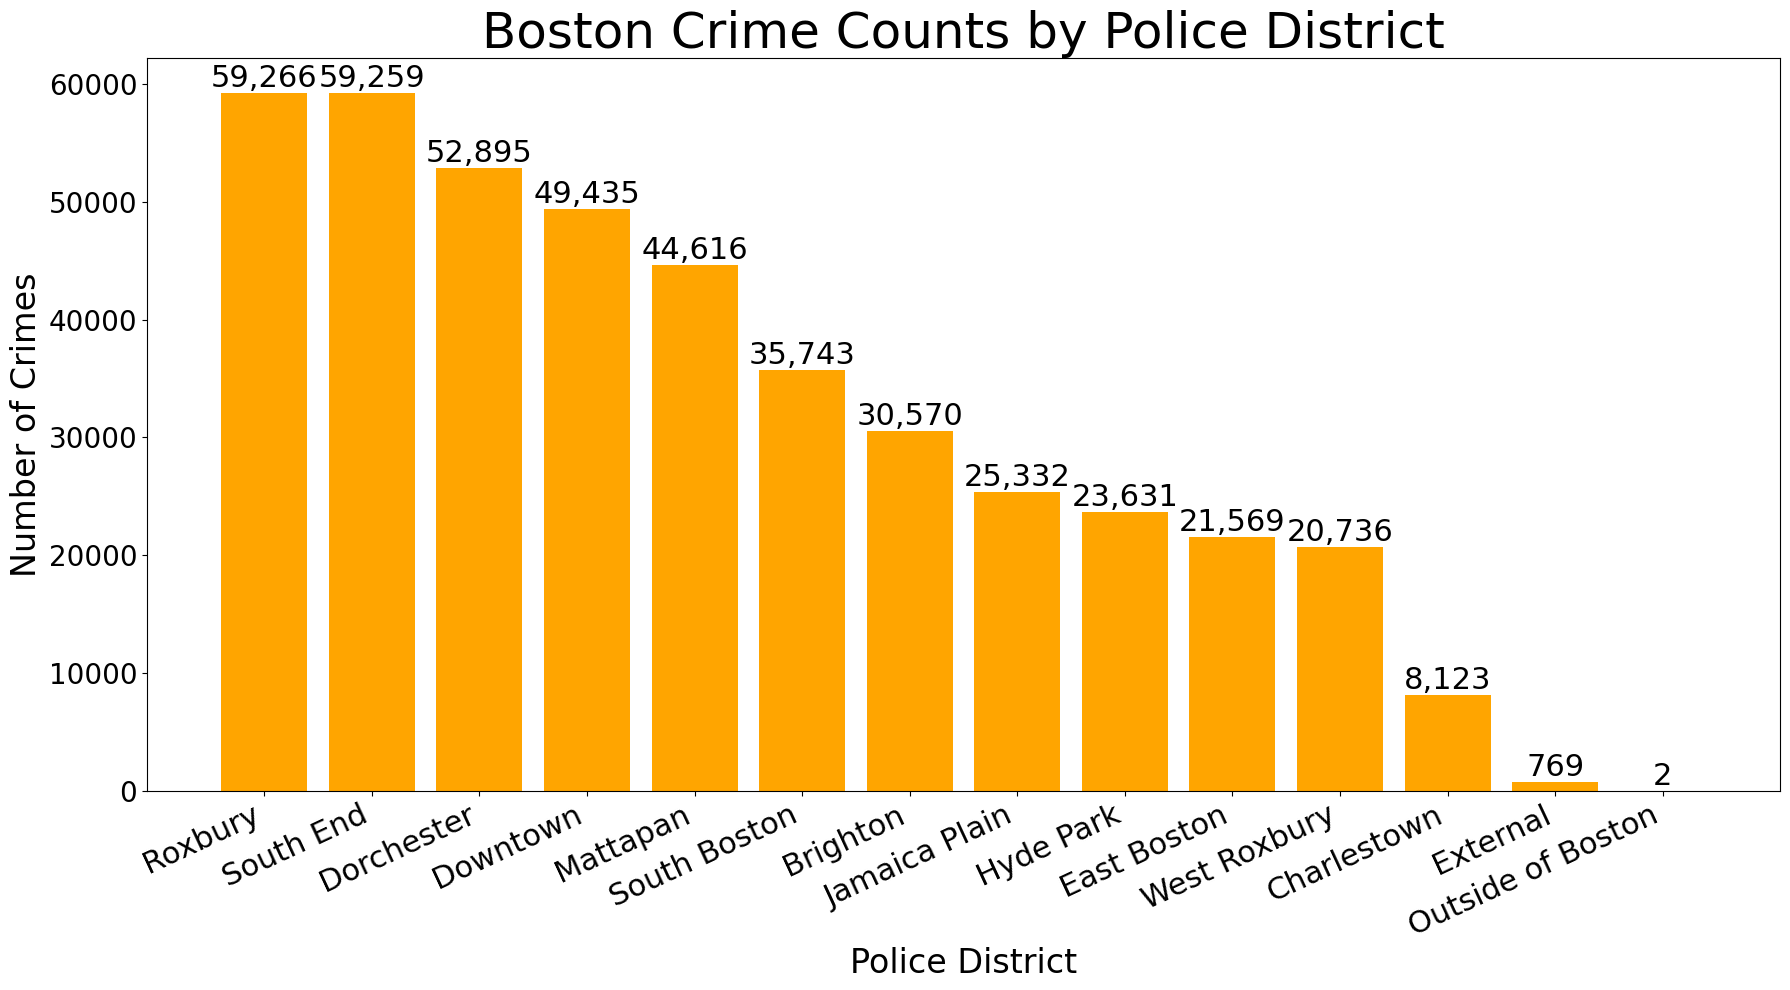

In [9]:
# crime count visualization
district_map = {
    "A1": "Downtown",
    "A7": "East Boston",
    "A15": "Charlestown",
    "B2": "Roxbury",
    "B3": "Mattapan",
    "C6": "South Boston",
    "C11": "Dorchester",
    "D4": "South End",
    "D14": "Brighton",
    "E5": "West Roxbury",
    "E13": "Jamaica Plain",
    "E18": "Hyde Park",
    "External": "External",
    "Outside of Boston": "Outside of Boston",
    "Outside of": "Outside of Boston",
}

df['DISTRICT_CLEAN'] = df['DISTRICT'].astype(str).str.strip()
df['DISTRICT_NAME'] = df['DISTRICT_CLEAN'].map(district_map)

df = df[df['DISTRICT_NAME'].notna()].copy()

counts = (
    df.groupby('DISTRICT_NAME')
      .size()
      .reset_index(name='Count')
      .sort_values('Count', ascending=False)
)

plt.figure(figsize=(18, 10))
plt.bar(counts['DISTRICT_NAME'], counts['Count'], color='orange')
plt.title('Boston Crime Counts by Police District', fontsize=36)
plt.xlabel('Police District', fontsize=24)
plt.ylabel('Number of Crimes', fontsize=24)
plt.xticks(rotation=25, ha='right', fontsize=22)
plt.yticks(fontsize=20)
plt.tight_layout()

for i, y in enumerate(counts['Count']):
    plt.text(i, y, f"{int(y):,}", ha='center', va='bottom', fontsize=22)

plt.show()
